# ML Zoomcamp 2026 — Homework 2: Regresión
Objetivo: predecir `fuel_efficiency_mpg` con regresión lineal implementada desde cero (ecuación normal).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

## Datos
Solo usamos las 5 columnas que pide el enunciado.

In [2]:
url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = pd.read_csv(url)[cols]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## EDA: ¿la variable objetivo tiene cola larga?

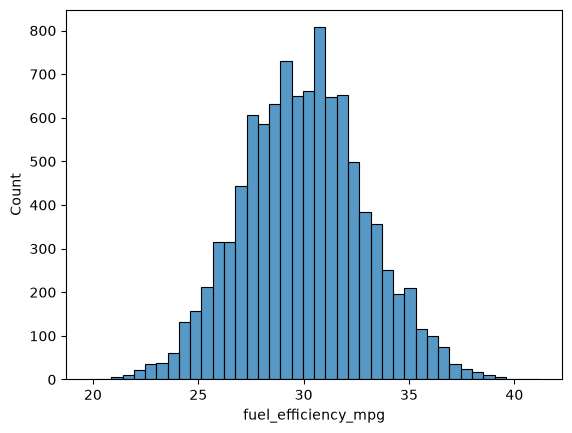

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

In [3]:
sns.histplot(df['fuel_efficiency_mpg'], bins=40)
plt.show()
df['fuel_efficiency_mpg'].describe()

No tiene cola larga: la distribución es bastante simétrica (alrededor de 30 mpg), así que **no** se aplica `log1p` como en la lección de precios.

## Q1. Columna con valores faltantes

In [4]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2. Mediana de `horsepower`

In [5]:
df['horsepower'].median()

np.float64(254.0)

## Funciones reutilizables
Split 60/20/20, regresión lineal (con regularización opcional `r`) y RMSE.

In [6]:
def split(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test


def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X) + r * np.eye(X.shape[1])
    w = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w[0], w[1:]


def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())


features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

def prepare_X(df, fill_value):
    return df[features].fillna({'horsepower': fill_value}).values

## Q3. Rellenar con 0 vs. con la media (media calculada **solo con train**)

In [7]:
df_train, df_val, df_test = split(df, 42)
y_train = df_train[target].values
y_val = df_val[target].values

mean_hp = df_train['horsepower'].mean()

for name, fill in [('con 0', 0), ('con la media', mean_hp)]:
    w0, w = train_linear_regression_reg(prepare_X(df_train, fill), y_train, r=0)
    y_pred = w0 + prepare_X(df_val, fill).dot(w)
    print(name, round(rmse(y_val, y_pred), 3))

con 0 2.205
con la media 2.202


## Q4. Mejor regularización `r` (NAs con 0, RMSE a 4 decimales)

In [8]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    print(r, round(rmse(y_val, y_pred), 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


## Q5. Estabilidad del modelo según la semilla

In [9]:
scores = []
for seed in range(10):
    tr, va, te = split(df, seed)
    w0, w = train_linear_regression_reg(prepare_X(tr, 0), tr[target].values, r=0)
    y_pred = w0 + prepare_X(va, 0).dot(w)
    scores.append(rmse(va[target].values, y_pred))

print(np.round(scores, 3))
round(np.std(scores), 3)

[2.239 2.202 2.163 2.204 2.202 2.246 2.27  2.191 2.217 2.207]


np.float64(0.029)

## Q6. Evaluación final en test (seed 9, train+val, r=0.001)

In [10]:
df_train, df_val, df_test = split(df, 9)
df_full_train = pd.concat([df_train, df_val])

w0, w = train_linear_regression_reg(prepare_X(df_full_train, 0), df_full_train[target].values, r=0.001)
y_pred = w0 + prepare_X(df_test, 0).dot(w)
rmse(df_test[target].values, y_pred)

np.float64(2.235827747191731)